# EDA - Passos Mágicos | PEDE 2022-2024

Notebook de análise exploratória da base `BASE DE DADOS PEDE 2024 - DATATHON.xlsx`, estruturado para responder às dores de negócio da Passos Mágicos e preparar hipóteses/variáveis para uma etapa posterior de Machine Learning.

**Perguntas cobertas**
- **IAN:** perfil de defasagem dos alunos e evolução anual.
- **IDA:** evolução do desempenho acadêmico por ano e fase.
- **IEG:** relação entre engajamento, desempenho acadêmico e ponto de virada.
- **IAA:** coerência entre autoavaliação, desempenho real e engajamento.
- **IPS:** sinais psicossociais antes de quedas em desempenho ou engajamento.
- **IPP:** convergência ou contradição entre avaliação psicopedagógica e defasagem.
- **IPV:** comportamentos mais associados ao ponto de virada.
- **INDE:** combinações multidimensionais que elevam a nota global.


## Contexto de negócio em linguagem simples

A Passos Mágicos não olha apenas para nota escolar. A organização acompanha o desenvolvimento do aluno por um índice composto, o **INDE**, que junta dimensões acadêmicas, psicossociais e psicopedagógicas.

Em termos práticos, o problema de negócio é responder:

- **Quem está defasado em relação à fase esperada para a idade?**
- **Quem tem bom desempenho acadêmico, mas baixo engajamento?**
- **Quem se percebe bem, mas tem desempenho ou engajamento baixo?**
- **Quais sinais psicossociais ou psicopedagógicos podem antecipar queda futura?**
- **Quais combinações de indicadores elevam ou reduzem o INDE?**

### Como os indicadores se organizam

| Dimensão | Indicadores | Leitura de negócio |
|---|---|---|
| Acadêmica | `IAN`, `IDA`, `IEG` | Nível adequado, desempenho e engajamento nas atividades |
| Psicossocial | `IAA`, `IPS` | Autopercepção do aluno e avaliação psicossocial |
| Psicopedagógica / Conselho | `IPP`, `IPV` | Aspectos pedagógicos, emocionais e ponto de virada |
| Síntese | `INDE` | Nota global ponderada do desenvolvimento educacional |

Importante: os anexos e tabelas de referência foram usados aqui como **contexto de negócio** para explicar os campos. A análise estatística abaixo continua sendo feita a partir da base Excel carregada no notebook.


## 1. Setup

A primeira célula carrega bibliotecas e tenta aproveitar o `openpyxl` do runtime embutido do Codex caso o kernel local do Jupyter não tenha essa dependência instalada.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Caminho do runtime embutido usado nesta máquina. Ele ajuda principalmente com openpyxl.
BUNDLED_SITE_PACKAGES = Path(r"C:\Users\renat\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages")
try:
    import openpyxl  # noqa: F401
except ModuleNotFoundError:
    if BUNDLED_SITE_PACKAGES.exists():
        sys.path.append(str(BUNDLED_SITE_PACKAGES))
        import openpyxl  # noqa: F401
    else:
        raise

import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

try:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.impute import SimpleImputer
    from sklearn.inspection import permutation_importance
    from sklearn.metrics import mean_absolute_error, r2_score
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    SKLEARN_OK = True
except Exception as exc:
    SKLEARN_OK = False
    SKLEARN_ERROR = exc

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("ggplot")

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

print("Ambiente pronto.")
print("sklearn disponível:", SKLEARN_OK)

Ambiente pronto.
sklearn disponível: True


## 2. Leitura do Excel

Cada aba representa uma fotografia anual da PEDE. Como as colunas mudam entre 2022, 2023 e 2024, vamos primeiro ler tudo cru e depois padronizar.

In [2]:
DATA_DIR = Path.cwd()
EXCEL_FILE = DATA_DIR / "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"
DICTIONARY_FILE = DATA_DIR / "Dicionário Dados Datathon.pdf"

if not EXCEL_FILE.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {EXCEL_FILE}")

raw_sheets = pd.read_excel(EXCEL_FILE, sheet_name=None, engine="openpyxl")

sheet_overview = (
    pd.DataFrame(
        [
            {"aba": name, "linhas": df.shape[0], "colunas": df.shape[1]}
            for name, df in raw_sheets.items()
        ]
    )
    .sort_values("aba")
    .reset_index(drop=True)
)
display(sheet_overview)

display(
    pd.DataFrame(
        {
            "arquivo": [EXCEL_FILE.name, DICTIONARY_FILE.name],
            "existe": [EXCEL_FILE.exists(), DICTIONARY_FILE.exists()],
        }
    )
)

,aba,linhas,colunas
0,PEDE2022,860,42
1,PEDE2023,1014,48
2,PEDE2024,1156,50


,arquivo,existe
0,BASE DE DADOS PEDE 2024 - DATATHON.xlsx,True
1,Dicionário Dados Datathon.pdf,True


## 3. Padronização da base

Regras usadas:
- `ano` vem do nome da aba.
- `INDE` e `Pedra` sempre priorizam a coluna do ano atual da própria aba.
- `fase_ordem` transforma valores como `ALFA`, `FASE 1`, `1A` ou `7E` em uma ordem comparável.
- `defasagem < 0` indica aluno abaixo da fase ideal; `0` indica fase ideal; `> 0` indica acima da fase ideal.

In [3]:
def norm_col(value):
    text = str(value).strip()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(char for char in text if not unicodedata.combining(char))
    text = re.sub(r"[^a-zA-Z0-9]+", "_", text).strip("_").lower()
    return text


def first_existing(norm_to_original, *candidates):
    for candidate in candidates:
        if candidate in norm_to_original:
            return norm_to_original[candidate]
    return None


def build_column_map(columns, year):
    norm_to_original = {norm_col(col): col for col in columns}
    yy = str(year)[-2:]
    return {
        "ra": first_existing(norm_to_original, "ra"),
        "fase_raw": first_existing(norm_to_original, "fase"),
        "turma": first_existing(norm_to_original, "turma"),
        "nome_anonimizado": first_existing(norm_to_original, "nome_anonimizado", "nome"),
        "idade": first_existing(norm_to_original, "idade", "idade_22"),
        "genero": first_existing(norm_to_original, "genero"),
        "ano_ingresso": first_existing(norm_to_original, "ano_ingresso"),
        "instituicao": first_existing(norm_to_original, "instituicao_de_ensino"),
        "escola": first_existing(norm_to_original, "escola"),
        "situacao": first_existing(norm_to_original, "ativo_inativo", "ativo_inativo_1"),
        "inde": first_existing(norm_to_original, f"inde_{year}", f"inde_{yy}"),
        "pedra": first_existing(norm_to_original, f"pedra_{year}", f"pedra_{yy}"),
        "iaa": first_existing(norm_to_original, "iaa"),
        "ieg": first_existing(norm_to_original, "ieg"),
        "ips": first_existing(norm_to_original, "ips"),
        "ipp": first_existing(norm_to_original, "ipp"),
        "ida": first_existing(norm_to_original, "ida"),
        "mat": first_existing(norm_to_original, "matem", "mat"),
        "por": first_existing(norm_to_original, "portug", "por"),
        "ing": first_existing(norm_to_original, "ingles", "ing"),
        "indicado": first_existing(norm_to_original, "indicado"),
        "atingiu_pv": first_existing(norm_to_original, "atingiu_pv"),
        "ipv": first_existing(norm_to_original, "ipv"),
        "ian": first_existing(norm_to_original, "ian"),
        "fase_ideal": first_existing(norm_to_original, "fase_ideal"),
        "defasagem": first_existing(norm_to_original, "defasagem", "defas"),
    }


def canonical_pedra(value):
    if pd.isna(value):
        return np.nan
    base = unicodedata.normalize("NFKD", str(value).strip())
    base = "".join(char for char in base if not unicodedata.combining(char)).lower()
    mapping = {
        "quartzo": "Quartzo",
        "agata": "Ágata",
        "ametista": "Ametista",
        "topazio": "Topázio",
        "incluir": "INCLUIR",
    }
    return mapping.get(base, str(value).strip())


def parse_fase_ordem(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().upper()
    if text in {"ALFA", "FASE ALFA"}:
        return 0
    match = re.search(r"(\d+)", text)
    if match:
        return int(match.group(1))
    return np.nan


def status_defasagem(value):
    if pd.isna(value):
        return np.nan
    if value < 0:
        return "Abaixo da fase ideal"
    if value > 0:
        return "Acima da fase ideal"
    return "Na fase ideal"


def build_long_base(raw_sheets):
    frames = []
    audit_rows = []
    for sheet_name, df in raw_sheets.items():
        year_match = re.search(r"(20\d{2})", sheet_name)
        if not year_match:
            continue
        year = int(year_match.group(1))
        col_map = build_column_map(df.columns, year)
        out = pd.DataFrame(index=df.index)
        out["ano"] = year
        out["aba_origem"] = sheet_name
        for new_col, original_col in col_map.items():
            out[new_col] = df[original_col] if original_col else np.nan
            audit_rows.append({"ano": year, "campo_padronizado": new_col, "coluna_excel": original_col})
        frames.append(out)

    base = pd.concat(frames, ignore_index=True)
    numeric_cols = [
        "idade", "ano_ingresso", "inde", "iaa", "ieg", "ips", "ipp",
        "ida", "mat", "por", "ing", "ipv", "ian", "defasagem"
    ]
    for col in numeric_cols:
        base[col] = pd.to_numeric(base[col], errors="coerce")

    base["pedra"] = base["pedra"].map(canonical_pedra)
    base["fase_ordem"] = base["fase_raw"].map(parse_fase_ordem)
    base["status_defasagem"] = base["defasagem"].map(status_defasagem)
    base["defasagem_abs"] = base["defasagem"].abs()
    base["atraso_fase"] = np.where(base["defasagem"] < 0, -base["defasagem"], 0)

    return base, pd.DataFrame(audit_rows)


base, audit_columns = build_long_base(raw_sheets)

display(base.head())
display(audit_columns.pivot_table(index="campo_padronizado", columns="ano", values="coluna_excel", aggfunc="first"))
print(f"Base padronizada: {base.shape[0]:,} linhas e {base.shape[1]:,} colunas.")

,ano,aba_origem,ra,fase_raw,turma,nome_anonimizado,idade,genero,ano_ingresso,instituicao,escola,situacao,inde,pedra,iaa,ieg,ips,ipp,ida,mat,por,ing,indicado,atingiu_pv,ipv,ian,fase_ideal,defasagem,fase_ordem,status_defasagem,defasagem_abs,atraso_fase
0,2022,PEDE2022,RA-1,7,A,Aluno-1,19.000,Menina,2016,Escola Pública,NaN,NaN,5.783,Quartzo,8.300,4.100,5.600,NaN,4.000,2.700,3.500,6.000,Sim,Não,7.278,5.000,Fase 8 (Universitários),-1,7,Abaixo da fase ideal,1,1
1,2022,PEDE2022,RA-2,7,A,Aluno-2,17.000,Menina,2017,Rede Decisão,NaN,NaN,7.055,Ametista,8.800,5.200,6.300,NaN,6.800,6.300,4.500,9.700,Não,Não,6.778,10.000,Fase 7 (3º EM),0,7,Na fase ideal,0,0
2,2022,PEDE2022,RA-3,7,A,Aluno-3,17.000,Menina,2016,Rede Decisão,NaN,NaN,6.591,Ágata,0.000,7.900,5.600,NaN,5.600,5.800,4.000,6.900,Não,Não,7.556,10.000,Fase 7 (3º EM),0,7,Na fase ideal,0,0
3,2022,PEDE2022,RA-4,7,A,Aluno-4,17.000,Menino,2017,Rede Decisão,NaN,NaN,5.951,Quartzo,8.800,4.500,5.600,NaN,5.000,2.800,3.500,8.700,Não,Não,5.278,10.000,Fase 7 (3º EM),0,7,Na fase ideal,0,0
4,2022,PEDE2022,RA-5,7,A,Aluno-5,17.000,Menina,2016,Rede Decisão,NaN,NaN,7.427,Ametista,7.900,8.600,5.600,NaN,5.200,7.000,2.900,5.700,Não,Não,7.389,10.000,Fase 7 (3º EM),0,7,Na fase ideal,0,0


ano,2022,2023,2024
campo_padronizado,,,
ano_ingresso,Ano ingresso,Ano ingresso,Ano ingresso
atingiu_pv,Atingiu PV,Atingiu PV,Atingiu PV
defasagem,Defas,Defasagem,Defasagem
escola,NaN,NaN,Escola
fase_ideal,Fase ideal,Fase Ideal,Fase Ideal
fase_raw,Fase,Fase,Fase
genero,Gênero,Gênero,Gênero
iaa,IAA,IAA,IAA
ian,IAN,IAN,IAN


Base padronizada: 3,030 linhas e 32 colunas.


# 1.1  Target para desempenho do Aluno: PEDRA

In [7]:
base[base['pedra'] == "Quartzo"].head(10)

,ano,aba_origem,ra,fase_raw,turma,nome_anonimizado,idade,genero,ano_ingresso,instituicao,escola,situacao,inde,pedra,iaa,ieg,ips,ipp,ida,mat,por,ing,indicado,atingiu_pv,ipv,ian,fase_ideal,defasagem,fase_ordem,status_defasagem,defasagem_abs,atraso_fase
0,2022,PEDE2022,RA-1,7,A,Aluno-1,19.000,Menina,2016,Escola Pública,NaN,NaN,5.783,Quartzo,8.300,4.100,5.600,NaN,4.000,2.700,3.500,6.000,Sim,Não,7.278,5.000,Fase 8 (Universitários),-1,7,Abaixo da fase ideal,1,1
3,2022,PEDE2022,RA-4,7,A,Aluno-4,17.000,Menino,2017,Rede Decisão,NaN,NaN,5.951,Quartzo,8.800,4.500,5.600,NaN,5.000,2.800,3.500,8.700,Não,Não,5.278,10.000,Fase 7 (3º EM),0,7,Na fase ideal,0,0
5,2022,PEDE2022,RA-6,7,A,Aluno-6,18.000,Menina,2021,Escola Pública,NaN,NaN,5.848,Quartzo,7.900,4.500,7.500,NaN,3.300,2.300,5.300,2.300,Sim,Não,7.222,5.000,Fase 8 (Universitários),-1,7,Abaixo da fase ideal,1,1
7,2022,PEDE2022,RA-8,7,A,Aluno-8,20.000,Menina,2018,Escola Pública,NaN,NaN,4.786,Quartzo,7.100,4.600,6.300,NaN,1.600,1.200,0.700,2.900,Não,Não,6.278,5.000,Fase 8 (Universitários),-1,7,Abaixo da fase ideal,1,1
9,2022,PEDE2022,RA-10,7,A,Aluno-10,18.000,Menina,2021,Escola Pública,NaN,NaN,5.784,Quartzo,8.300,5.200,5.000,NaN,4.100,3.300,2.600,6.400,Não,Não,7.056,5.000,Fase 8 (Universitários),-1,7,Abaixo da fase ideal,1,1
10,2022,PEDE2022,RA-11,7,A,Aluno-11,18.000,Menina,2016,Escola Pública,NaN,NaN,5.323,Quartzo,9.200,4.200,5.000,NaN,3.000,1.800,2.500,4.500,Não,Não,6.389,5.000,Fase 8 (Universitários),-1,7,Abaixo da fase ideal,1,1
11,2022,PEDE2022,RA-12,7,A,Aluno-12,17.000,Menina,2020,Escola Pública,NaN,NaN,4.832,Quartzo,0.000,4.000,6.900,NaN,1.500,2.700,1.100,0.700,Sim,Não,6.389,10.000,Fase 7 (3º EM),0,7,Na fase ideal,0,0
28,2022,PEDE2022,RA-29,6,A,Aluno-29,17.000,Menino,2022,Escola Pública,NaN,NaN,4.985,Quartzo,0.000,4.000,8.800,NaN,3.700,6.300,1.100,3.800,Sim,Não,7.611,5.000,Fase 7 (3º EM),-1,6,Abaixo da fase ideal,1,1
32,2022,PEDE2022,RA-33,6,A,Aluno-33,17.000,Menina,2020,Escola Pública,NaN,NaN,4.952,Quartzo,0.000,4.600,7.500,NaN,4.800,9.000,1.600,3.700,Não,Não,6.000,5.000,Fase 7 (3º EM),-1,6,Abaixo da fase ideal,1,1
36,2022,PEDE2022,RA-37,6,A,Aluno-37,17.000,Menina,2019,Rede Decisão,NaN,NaN,4.950,Quartzo,0.000,5.400,5.000,NaN,5.900,2.300,5.300,10.000,Não,Não,5.222,5.000,Fase 7 (3º EM),-1,6,Abaixo da fase ideal,1,1


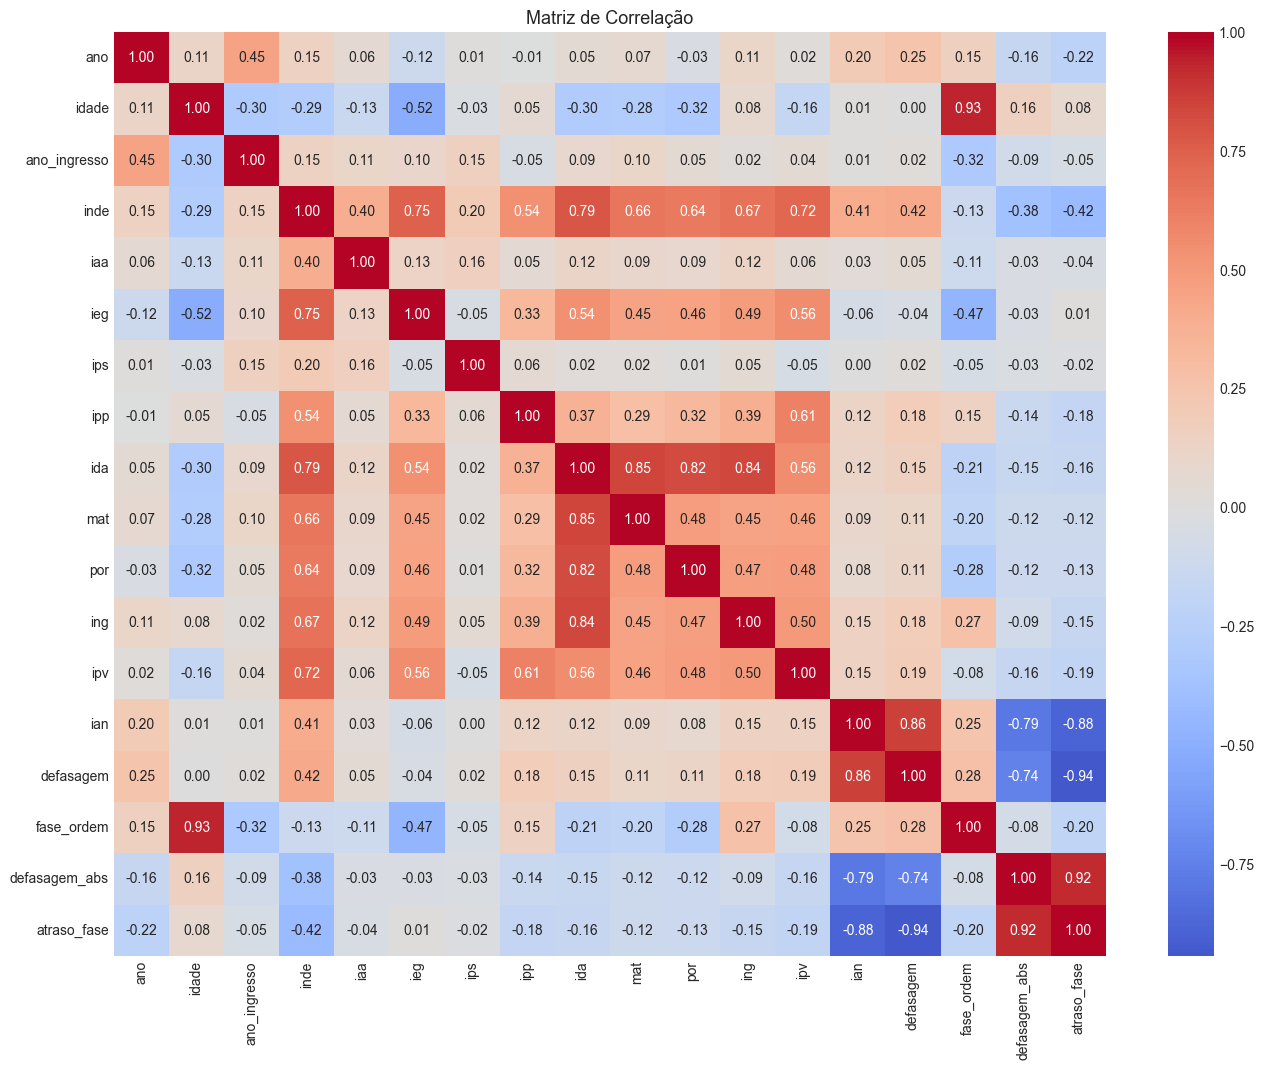

In [9]:
import seaborn as sns

base_correlation = base.select_dtypes(include=['number'])
correlation = base_correlation.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação")
plt.show()

## 4. Qualidade dos dados e leitura inicial

Antes de responder às dores de negócio, verificamos volume, duplicidades, nulos e estatísticas gerais. Isso evita treinar modelos em campos com cobertura fraca ou com mudança de definição entre anos.

In [19]:
indicadores = ["ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv", "inde"]

volume = (
    base.groupby("ano")
    .agg(
        alunos=("ra", "count"),
        ras_unicos=("ra", "nunique"),
        fases=("fase_ordem", "nunique"),
        inde_cobertura=("inde", lambda s: s.notna().mean()),
        ipp_cobertura=("ipp", lambda s: s.notna().mean()),
    )
    .assign(
        inde_cobertura=lambda df: df["inde_cobertura"].mul(100),
        ipp_cobertura=lambda df: df["ipp_cobertura"].mul(100),
    )
)

nulos_cols = indicadores + ["defasagem", "fase_ordem", "idade"]
nulos = (
    base.groupby("ano")[nulos_cols]
    .agg(lambda serie: serie.isna().mean() * 100)
    .round(1)
)

estatisticas = (
    base.groupby("ano")[indicadores + ["defasagem"]]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

display(volume.round(1))
display(nulos)
display(estatisticas)

ras_por_ano = {ano: set(df["ra"].dropna().astype(str)) for ano, df in base.groupby("ano")}
intersecao = []
anos = sorted(ras_por_ano)
for i, ano_a in enumerate(anos):
    for ano_b in anos[i + 1:]:
        intersecao.append({
            "par_anos": f"{ano_a}-{ano_b}",
            "alunos_em_ambos": len(ras_por_ano[ano_a] & ras_por_ano[ano_b])
        })
intersecao.append({"par_anos": "2022-2023-2024", "alunos_em_ambos": len(set.intersection(*ras_por_ano.values()))})
display(pd.DataFrame(intersecao))

,alunos,ras_unicos,fases,inde_cobertura,ipp_cobertura
ano,,,,,
2022,860,860,8,100.000,0.000
2023,1014,1014,9,91.800,92.500
2024,1156,1156,10,91.200,91.200


,ian,ida,ieg,iaa,ips,ipp,ipv,inde,defasagem,fase_ordem,idade
ano,,,,,,,,,,,
2022,0.000,0.000,0.000,0.000,0.000,100.000,0.000,0.000,0.000,0.000,0.000
2023,0.000,7.600,7.500,6.200,6.800,7.500,7.500,8.200,0.000,0.000,39.300
2024,0.000,8.700,0.000,8.800,8.800,8.800,8.800,8.800,0.000,0.000,0.000


ian                      ida                      ieg               \
     count  mean median   std count  mean median   std count  mean median   
ano                                                                         
2022   860 6.424  5.000 2.390   860 6.093  6.300 2.046   860 7.891  8.300   
2023  1014 7.244  5.000 2.540   937 6.663  6.800 1.595   938 8.699  9.000   
2024  1156 7.684 10.000 2.504  1055 6.351  6.750 2.132  1156 7.375  8.333   

             iaa                      ips                      ipp        \
       std count  mean median   std count  mean median   std count  mean   
ano                                                                        
2022 1.638   860 8.274  8.800 2.065   860 6.905  7.500 1.071     0   NaN   
2023 1.084   951 6.903  8.500 3.590   945 5.120  5.000 2.090   938 7.563   
2024 2.847  1054 8.544  8.751 1.491  1054 6.830  7.510 1.428  1054 7.548   

                    ipv                     inde                    defasagem  \
     median   std count  mean median   std count  mean median   std     count   
ano                                                                             
2022    NaN   NaN   860 7.254  7.333 1.093   860 7.036  7.197 1.018       860   
2023  7.656 0.984   938 8.028  8.045 0.945   931 7.342  7.408 0.902      1014   
2024  7.500 0.897  1054 7.354  7.500 1.049  1054 7.397  7.540 1.014      1156   

                          
       mean median   std  
ano                       
2022 -0.943 -1.000 0.846  
2023 -0.655 -1.000 0.821  
2024 -0.409  0.000 0.850

,par_anos,alunos_em_ambos
0,2022-2023,600
1,2022-2024,472
2,2023-2024,765
3,2022-2023-2024,468


## 5. Dicionário analítico dos indicadores

O dicionário de dados informa que o `INDE` é a métrica global ponderada a partir dos indicadores abaixo. Nesta EDA, os indicadores são tratados como notas numéricas e analisados em relação a tendência, consistência e poder preditivo.

In [20]:
metricas_info = pd.DataFrame(
    [
        {
            "indicador": "IAN",
            "dimensao": "Acadêmica",
            "nome": "Indicador de Adequação ao Nível",
            "regra_ou_formula": "D = Fase efetiva - Fase ideal. Pela base: D >= 0 => IAN 10; -2 <= D < 0 => IAN 5; D < -2 => IAN 2,5.",
            "dados_necessarios": "Fase atual do estudante e fase ideal conforme idade.",
            "o_que_exploramos": "Perfil de defasagem e evolução dos alunos ao longo dos anos.",
            "uso_para_ml": "Feature de risco de defasagem e atraso escolar.",
        },
        {
            "indicador": "IDA",
            "dimensao": "Acadêmica",
            "nome": "Indicador de Desempenho Acadêmico",
            "regra_ou_formula": "IDA = média das notas acadêmicas. Na leitura simplificada: (Matemática + Português + Inglês) / 3.",
            "dados_necessarios": "Notas internas da Associação e avaliações acadêmicas.",
            "o_que_exploramos": "Se o desempenho acadêmico melhora, cai ou estagna por ano e fase.",
            "uso_para_ml": "Alvo ou feature para prever INDE, queda futura e priorização pedagógica.",
        },
        {
            "indicador": "IEG",
            "dimensao": "Acadêmica",
            "nome": "Indicador de Engajamento",
            "regra_ou_formula": "IEG = soma das pontuações das tarefas realizadas / número de tarefas.",
            "dados_necessarios": "Registros de lição de casa, atividades, entregas e voluntariado.",
            "o_que_exploramos": "Relação entre engajamento, IDA e IPV.",
            "uso_para_ml": "Feature comportamental para prever desempenho, evasão/risco e ponto de virada.",
        },
        {
            "indicador": "IAA",
            "dimensao": "Psicossocial",
            "nome": "Indicador de Autoavaliação",
            "regra_ou_formula": "IAA = soma das pontuações das respostas / número de perguntas. Escala de 0 a 10.",
            "dados_necessarios": "Questionário de autoavaliação individual.",
            "o_que_exploramos": "Coerência entre autopercepção, desempenho real e engajamento.",
            "uso_para_ml": "Feature de percepção e gaps IAA-IDA / IAA-IEG.",
        },
        {
            "indicador": "IPS",
            "dimensao": "Psicossocial",
            "nome": "Indicador Psicossocial",
            "regra_ou_formula": "IPS = soma das pontuações dos avaliadores / número de avaliadores.",
            "dados_necessarios": "Avaliações de psicólogos sobre aspectos comportamentais, emocionais e sociais.",
            "o_que_exploramos": "Se sinais psicossociais antecedem queda de desempenho ou engajamento.",
            "uso_para_ml": "Feature preventiva para risco futuro, especialmente em análise longitudinal.",
        },
        {
            "indicador": "IPP",
            "dimensao": "Psicopedagógica",
            "nome": "Indicador Psicopedagógico",
            "regra_ou_formula": "IPP = soma das avaliações sobre aspectos pedagógicos / número de avaliações.",
            "dados_necessarios": "Questionários e avaliações de educadores/psicopedagogos.",
            "o_que_exploramos": "Se o IPP confirma ou contradiz a defasagem observada pelo IAN.",
            "uso_para_ml": "Feature para diferenciar defasagem acadêmica de risco psicopedagógico.",
        },
        {
            "indicador": "IPV",
            "dimensao": "Psicopedagógica / Conselho",
            "nome": "Indicador do Ponto de Virada",
            "regra_ou_formula": "IPV sintetiza análises longitudinais de progresso acadêmico, engajamento e desenvolvimento emocional.",
            "dados_necessarios": "Avaliações longitudinais de educadores, psicopedagogos e histórico do aluno.",
            "o_que_exploramos": "Quais comportamentos e indicadores mais se associam ao ponto de virada.",
            "uso_para_ml": "Alvo ou feature para prever evolução positiva e priorizar intervenções.",
        },
        {
            "indicador": "INDE",
            "dimensao": "Síntese multidimensional",
            "nome": "Índice de Desenvolvimento Educacional",
            "regra_ou_formula": "Fases 0 a 7: IAN*0,1 + IDA*0,2 + IEG*0,2 + IAA*0,1 + IPS*0,1 + IPP*0,1 + IPV*0,2. Fase 8: IAN*0,1 + IDA*0,4 + IEG*0,2 + IAA*0,1 + IPS*0,2.",
            "dados_necessarios": "Indicadores componentes com pesos por faixa de fase.",
            "o_que_exploramos": "Quais combinações de indicadores elevam mais a nota global.",
            "uso_para_ml": "Principal alvo de regressão/ranking, com cuidado para evitar vazamento de dados.",
        },
    ]
)
display(metricas_info)

,indicador,dimensao,nome,regra_ou_formula,dados_necessarios,o_que_exploramos,uso_para_ml
0,IAN,Acadêmica,Indicador de Adequação ao Nível,D = Fase efetiva - Fase ideal. Pela base: D >=...,Fase atual do estudante e fase ideal conforme ...,Perfil de defasagem e evolução dos alunos ao l...,Feature de risco de defasagem e atraso escolar.
1,IDA,Acadêmica,Indicador de Desempenho Acadêmico,IDA = média das notas acadêmicas. Na leitura s...,Notas internas da Associação e avaliações acad...,"Se o desempenho acadêmico melhora, cai ou esta...","Alvo ou feature para prever INDE, queda futura..."
2,IEG,Acadêmica,Indicador de Engajamento,IEG = soma das pontuações das tarefas realizad...,"Registros de lição de casa, atividades, entreg...","Relação entre engajamento, IDA e IPV.","Feature comportamental para prever desempenho,..."
3,IAA,Psicossocial,Indicador de Autoavaliação,IAA = soma das pontuações das respostas / núme...,Questionário de autoavaliação individual.,"Coerência entre autopercepção, desempenho real...",Feature de percepção e gaps IAA-IDA / IAA-IEG.
4,IPS,Psicossocial,Indicador Psicossocial,IPS = soma das pontuações dos avaliadores / nú...,Avaliações de psicólogos sobre aspectos compor...,Se sinais psicossociais antecedem queda de des...,"Feature preventiva para risco futuro, especial..."
5,IPP,Psicopedagógica,Indicador Psicopedagógico,IPP = soma das avaliações sobre aspectos pedag...,Questionários e avaliações de educadores/psico...,Se o IPP confirma ou contradiz a defasagem obs...,Feature para diferenciar defasagem acadêmica d...
6,IPV,Psicopedagógica / Conselho,Indicador do Ponto de Virada,IPV sintetiza análises longitudinais de progre...,"Avaliações longitudinais de educadores, psicop...",Quais comportamentos e indicadores mais se ass...,Alvo ou feature para prever evolução positiva ...
7,INDE,Síntese multidimensional,Índice de Desenvolvimento Educacional,"Fases 0 a 7: IAN*0,1 + IDA*0,2 + IEG*0,2 + IAA...",Indicadores componentes com pesos por faixa de...,Quais combinações de indicadores elevam mais a...,"Principal alvo de regressão/ranking, com cuida..."



## 5.1 Regras de negócio dos indicadores e pesos do INDE

Esta etapa traduz as tabelas de referência da Passos Mágicos em regras testáveis na base.

O objetivo aqui não é criar um modelo ainda, mas verificar se os campos da planilha se comportam de acordo com a lógica esperada:

- `IAN` deve refletir a defasagem entre fase efetiva e fase ideal.
- `INDE` deve refletir a soma ponderada dos indicadores.
- Os pesos mudam para a Fase 8, então análises e modelos precisam respeitar essa diferença.


In [21]:

pesos_inde = pd.DataFrame(
    [
        {"faixa_fase": "Fases 0 a 7", "indicador": "IAN", "peso": 0.10},
        {"faixa_fase": "Fases 0 a 7", "indicador": "IDA", "peso": 0.20},
        {"faixa_fase": "Fases 0 a 7", "indicador": "IEG", "peso": 0.20},
        {"faixa_fase": "Fases 0 a 7", "indicador": "IAA", "peso": 0.10},
        {"faixa_fase": "Fases 0 a 7", "indicador": "IPS", "peso": 0.10},
        {"faixa_fase": "Fases 0 a 7", "indicador": "IPP", "peso": 0.10},
        {"faixa_fase": "Fases 0 a 7", "indicador": "IPV", "peso": 0.20},
        {"faixa_fase": "Fase 8", "indicador": "IAN", "peso": 0.10},
        {"faixa_fase": "Fase 8", "indicador": "IDA", "peso": 0.40},
        {"faixa_fase": "Fase 8", "indicador": "IEG", "peso": 0.20},
        {"faixa_fase": "Fase 8", "indicador": "IAA", "peso": 0.10},
        {"faixa_fase": "Fase 8", "indicador": "IPS", "peso": 0.20},
    ]
)


def ian_pela_regra_defasagem(defasagem):
    if pd.isna(defasagem):
        return np.nan
    if defasagem >= 0:
        return 10.0
    if defasagem >= -2:
        return 5.0
    return 2.5


def pesos_por_fase(fase_ordem):
    if fase_ordem == 8:
        return {"ian": 0.10, "ida": 0.40, "ieg": 0.20, "iaa": 0.10, "ips": 0.20}
    return {"ian": 0.10, "ida": 0.20, "ieg": 0.20, "iaa": 0.10, "ips": 0.10, "ipp": 0.10, "ipv": 0.20}


def calcula_inde_regrado(row):
    pesos = pesos_por_fase(row["fase_ordem"])
    if any(pd.isna(row[indicador]) for indicador in pesos):
        return np.nan
    return sum(row[indicador] * peso for indicador, peso in pesos.items())


base["ian_pela_regra_defasagem"] = base["defasagem"].map(ian_pela_regra_defasagem)
base["ian_bate_regra_defasagem"] = np.isclose(base["ian"], base["ian_pela_regra_defasagem"], equal_nan=True)
base["inde_recalculado_pelos_pesos"] = base.apply(calcula_inde_regrado, axis=1)
base["dif_inde_base_recalculado"] = base["inde"] - base["inde_recalculado_pelos_pesos"]
base["abs_dif_inde_base_recalculado"] = base["dif_inde_base_recalculado"].abs()

display(Markdown("**Pesos oficiais usados para interpretar o INDE:**"))
display(pesos_inde.pivot(index="indicador", columns="faixa_fase", values="peso").fillna("N/A"))

display(Markdown("**Validação da regra IAN a partir da defasagem:**"))
display(
    base.groupby(["defasagem", "ian"], dropna=False)
    .size()
    .rename("alunos")
    .reset_index()
    .sort_values(["defasagem", "ian"])
)

display(Markdown("**Validação do INDE recalculado pelos pesos oficiais:**"))
display(
    base.groupby("ano")
    .agg(
        alunos_com_inde=("inde", "count"),
        alunos_com_formula_completa=("inde_recalculado_pelos_pesos", "count"),
        diferenca_media_abs=("abs_dif_inde_base_recalculado", "mean"),
        diferenca_mediana_abs=("abs_dif_inde_base_recalculado", "median"),
        diferenca_p95_abs=("abs_dif_inde_base_recalculado", lambda s: s.quantile(0.95)),
    )
    .round(4)
)

display(Markdown("""
**Leitura de negócio:** `IAN` é uma nota derivada da defasagem, não a defasagem bruta. Já o `INDE` é uma composição ponderada: nas Fases 0 a 7, `IDA`, `IEG` e `IPV` têm maior peso; na Fase 8, `IDA` ganha peso maior e `IPP`/`IPV` deixam de entrar na fórmula. Como `IPP` não está disponível em 2022 nesta base, o recálculo completo do `INDE` fica mais confiável para 2023 e 2024.
"""))


**Pesos oficiais usados para interpretar o INDE:**

faixa_fase,Fase 8,Fases 0 a 7
indicador,,
IAA,0.100,0.100
IAN,0.100,0.100
IDA,0.400,0.200
IEG,0.200,0.200
IPP,N/A,0.100
IPS,0.200,0.100
IPV,N/A,0.200


**Validação da regra IAN a partir da defasagem:**

,defasagem,ian,alunos
0,-5,2.500,1
1,-4,2.500,5
2,-3,2.500,39
3,-2,5.000,383
4,-1,5.000,1259
5,0,10.000,1152
6,1,10.000,165
7,2,10.000,24
8,3,10.000,2


**Validação do INDE recalculado pelos pesos oficiais:**

,alunos_com_inde,alunos_com_formula_completa,diferenca_media_abs,diferenca_mediana_abs,diferenca_p95_abs
ano,,,,,
2022,860,0,NaN,NaN,NaN
2023,931,931,0.005,0.005,0.010
2024,1054,1054,0.000,0.000,0.000



**Leitura de negócio:** `IAN` é uma nota derivada da defasagem, não a defasagem bruta. Já o `INDE` é uma composição ponderada: nas Fases 0 a 7, `IDA`, `IEG` e `IPV` têm maior peso; na Fase 8, `IDA` ganha peso maior e `IPP`/`IPV` deixam de entrar na fórmula. Como `IPP` não está disponível em 2022 nesta base, o recálculo completo do `INDE` fica mais confiável para 2023 e 2024.


In [22]:
def pct_fmt(value):
    if pd.isna(value):
        return "-"
    return f"{value * 100:.1f}%"


def add_bar_labels(ax, fmt="{:.1f}"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, label_type="edge", fontsize=9, padding=2)


def classifica_tendencia(delta, tolerancia=0.15):
    if pd.isna(delta):
        return "sem comparação"
    if delta > tolerancia:
        return "melhorando"
    if delta < -tolerancia:
        return "caindo"
    return "estagnado"


def corr_by_year(df, cols, target):
    rows = []
    for ano, group in df.groupby("ano"):
        corr = group[cols].corr(numeric_only=True)
        if target in corr.columns:
            values = corr[target].drop(labels=[target], errors="ignore")
            for indicador, value in values.items():
                rows.append({"ano": ano, "variavel": indicador, f"corr_{target}": value})
    return pd.DataFrame(rows).sort_values(["ano", f"corr_{target}"], ascending=[True, False])


def plot_scatter_with_fit(df, x, y, ax, title):
    plot_df = df[[x, y, "ano"]].dropna()
    for ano, group in plot_df.groupby("ano"):
        ax.scatter(group[x], group[y], s=18, alpha=0.45, label=str(ano))
    if len(plot_df) > 2:
        coef = np.polyfit(plot_df[x], plot_df[y], 1)
        xs = np.linspace(plot_df[x].min(), plot_df[x].max(), 100)
        ax.plot(xs, coef[0] * xs + coef[1], color="black", linewidth=2, label="tendência geral")
    ax.set_title(title)
    ax.set_xlabel(x.upper())
    ax.set_ylabel(y.upper())
    ax.legend(title="Ano", frameon=True)

## 6. IAN - Perfil de defasagem e evolução

Pergunta de negócio: **qual é o perfil geral de defasagem dos alunos e como ele evolui ao longo dos anos?**

,alunos,ian_medio,ian_mediana,pct_ian_menor_7,defasagem_media,pct_abaixo_fase,pct_na_fase,pct_acima_fase
ano,,,,,,,,
2022,860,6.424,5.000,0.699,-0.943,0.699,0.287,0.014
2023,1014,7.244,5.000,0.544,-0.655,0.544,0.414,0.041
2024,1156,7.684,10.000,0.462,-0.409,0.462,0.420,0.119


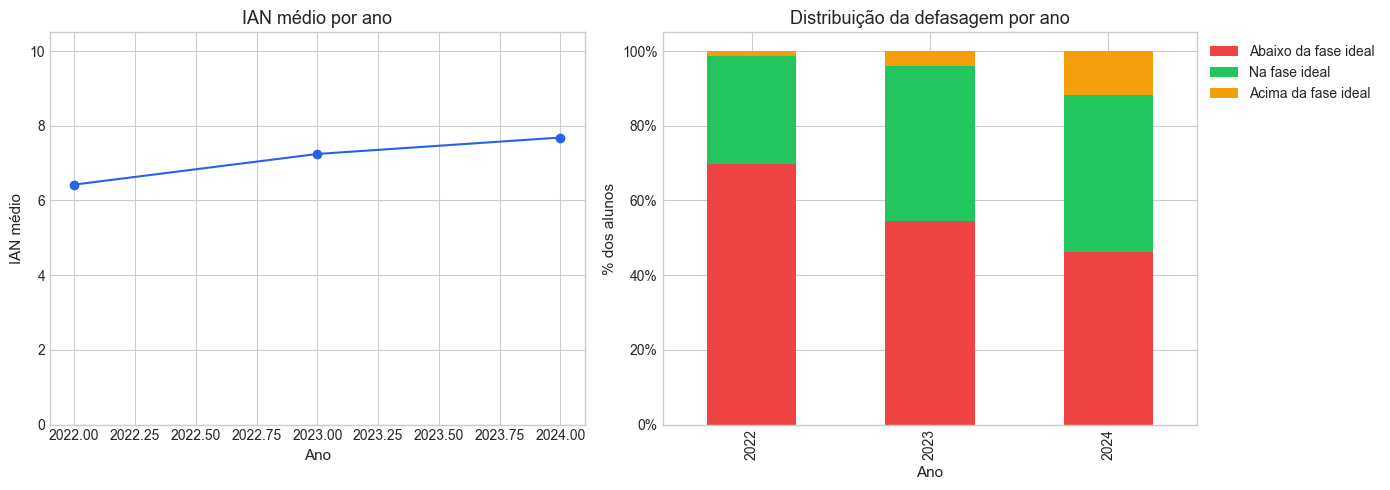


**Leitura analítica:** o IAN médio saiu de **6.42** em 2022 para **7.68** em 2024, variação de **+1.26 ponto(s)**. A proporção abaixo da fase ideal variou de **69.9%** para **46.2%**. Para ML, `ian`, `defasagem`, `atraso_fase` e `status_defasagem` são candidatos fortes para explicar risco educacional.


In [23]:
ian_year = (
    base.groupby("ano")
    .agg(
        alunos=("ra", "count"),
        ian_medio=("ian", "mean"),
        ian_mediana=("ian", "median"),
        pct_ian_menor_7=("ian", lambda s: s.lt(7).mean()),
        defasagem_media=("defasagem", "mean"),
        pct_abaixo_fase=("defasagem", lambda s: s.lt(0).mean()),
        pct_na_fase=("defasagem", lambda s: s.eq(0).mean()),
        pct_acima_fase=("defasagem", lambda s: s.gt(0).mean()),
    )
    .round(3)
)

display(ian_year)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ian_year["ian_medio"].plot(marker="o", ax=axes[0], color="#2563eb")
axes[0].set_title("IAN médio por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("IAN médio")
axes[0].set_ylim(0, 10.5)

defas_dist = (
    pd.crosstab(base["ano"], base["status_defasagem"], normalize="index")
    .reindex(columns=["Abaixo da fase ideal", "Na fase ideal", "Acima da fase ideal"])
    .fillna(0)
)
defas_dist.plot(kind="bar", stacked=True, ax=axes[1], color=["#ef4444", "#22c55e", "#f59e0b"])
axes[1].set_title("Distribuição da defasagem por ano")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("% dos alunos")
axes[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

delta_ian_22_24 = ian_year.loc[2024, "ian_medio"] - ian_year.loc[2022, "ian_medio"]
delta_abaixo_22_24 = ian_year.loc[2024, "pct_abaixo_fase"] - ian_year.loc[2022, "pct_abaixo_fase"]

display(Markdown(f'''
**Leitura analítica:** o IAN médio saiu de **{ian_year.loc[2022, 'ian_medio']:.2f}** em 2022 para **{ian_year.loc[2024, 'ian_medio']:.2f}** em 2024, variação de **{delta_ian_22_24:+.2f} ponto(s)**. A proporção abaixo da fase ideal variou de **{pct_fmt(ian_year.loc[2022, 'pct_abaixo_fase'])}** para **{pct_fmt(ian_year.loc[2024, 'pct_abaixo_fase'])}**. Para ML, `ian`, `defasagem`, `atraso_fase` e `status_defasagem` são candidatos fortes para explicar risco educacional.
'''))

## 7. IDA - Desempenho acadêmico por ano e fase

Pergunta de negócio: **o desempenho acadêmico médio está melhorando, estagnado ou caindo ao longo das fases e anos?**

,alunos_com_ida,ida_medio,ida_mediana,inde_medio,mat_medio,por_medio,ing_medio,delta_ida_vs_ano_anterior,status_tendencia
ano,,,,,,,,,
2022,860,6.093,6.300,7.036,5.807,6.321,5.881,NaN,sem comparação
2023,937,6.663,6.800,7.342,6.410,6.817,6.200,0.570,melhorando
2024,1055,6.351,6.750,7.397,6.230,6.176,6.596,-0.312,caindo


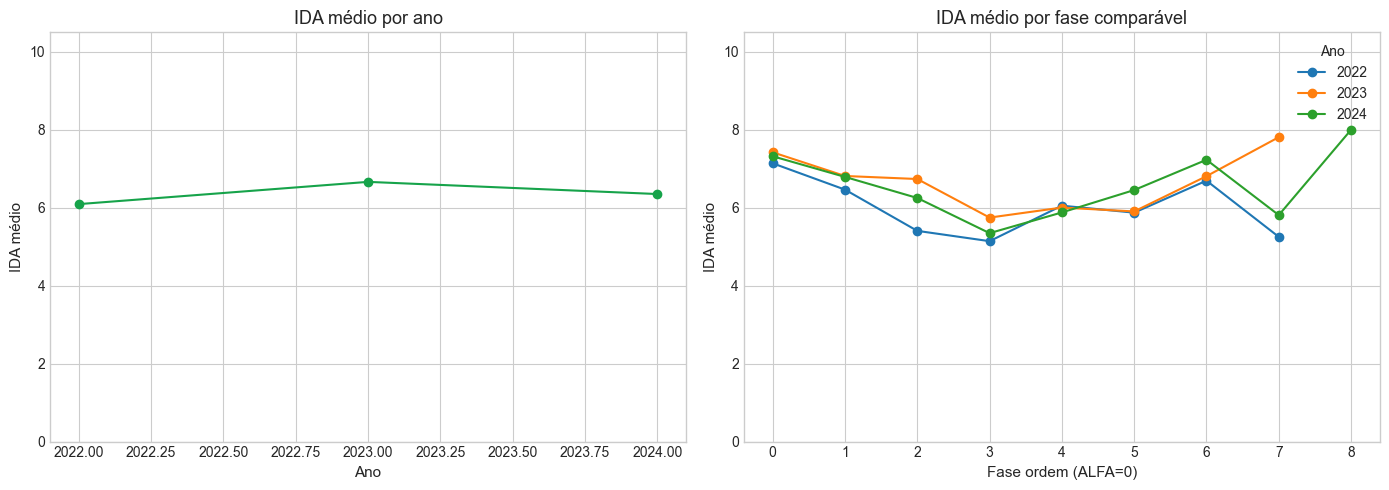


**Leitura analítica:** de 2023 para 2024 o IDA ficou **caindo** (-0.31). A visão por `fase_ordem` ajuda a separar efeito de ano de efeito de composição da turma/fase. Para modelagem, vale criar features de tendência do aluno, como `delta_ida` quando houver histórico por RA.


In [24]:
ida_year = (
    base.groupby("ano")
    .agg(
        alunos_com_ida=("ida", "count"),
        ida_medio=("ida", "mean"),
        ida_mediana=("ida", "median"),
        inde_medio=("inde", "mean"),
        mat_medio=("mat", "mean"),
        por_medio=("por", "mean"),
        ing_medio=("ing", "mean"),
    )
)
ida_year["delta_ida_vs_ano_anterior"] = ida_year["ida_medio"].diff()
ida_year["status_tendencia"] = ida_year["delta_ida_vs_ano_anterior"].map(classifica_tendencia)
display(ida_year.round(3))

fase_year = (
    base.dropna(subset=["fase_ordem"])
    .groupby(["ano", "fase_ordem"])
    .agg(alunos=("ra", "count"), ida_medio=("ida", "mean"), inde_medio=("inde", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ida_year["ida_medio"].plot(marker="o", ax=axes[0], color="#16a34a")
axes[0].set_title("IDA médio por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("IDA médio")
axes[0].set_ylim(0, 10.5)

for ano, group in fase_year.groupby("ano"):
    axes[1].plot(group["fase_ordem"], group["ida_medio"], marker="o", label=str(ano))
axes[1].set_title("IDA médio por fase comparável")
axes[1].set_xlabel("Fase ordem (ALFA=0)")
axes[1].set_ylabel("IDA médio")
axes[1].set_ylim(0, 10.5)
axes[1].legend(title="Ano")
plt.tight_layout()
plt.show()

delta_23_24 = ida_year.loc[2024, "ida_medio"] - ida_year.loc[2023, "ida_medio"]
display(Markdown(f'''
**Leitura analítica:** de 2023 para 2024 o IDA ficou **{classifica_tendencia(delta_23_24)}** ({delta_23_24:+.2f}). A visão por `fase_ordem` ajuda a separar efeito de ano de efeito de composição da turma/fase. Para modelagem, vale criar features de tendência do aluno, como `delta_ida` quando houver histórico por RA.
'''))

## 8. IEG - Engajamento versus IDA e IPV

Pergunta de negócio: **o grau de engajamento tem relação direta com desempenho acadêmico e ponto de virada?**

,corr_ieg_ida,corr_ieg_ipv,corr_ieg_inde
ano,,,
2022,0.564,0.589,0.802
2023,0.461,0.449,0.646
2024,0.538,0.535,0.787


alunos  ida_medio  ipv_medio  inde_medio
ano  quartil_ieg                                          
2022 Q1 baixo        257      4.626      6.459       6.013
     Q2              250      6.286      7.293       7.121
     Q3              232      6.906      7.713       7.608
     Q4 alto         121      7.252      7.978       7.938
2023 Q1 baixo        103      5.130      7.280       6.178
     Q2              273      6.222      7.684       6.961
     Q3              286      6.866      8.117       7.529
     Q4 alto         276      7.457      8.555       7.958
2024 Q1 baixo        386      4.821      6.567       6.322
     Q2              244      6.117      7.233       7.241
     Q3              232      6.957      7.636       7.814
     Q4 alto         294      7.551      7.993       8.234

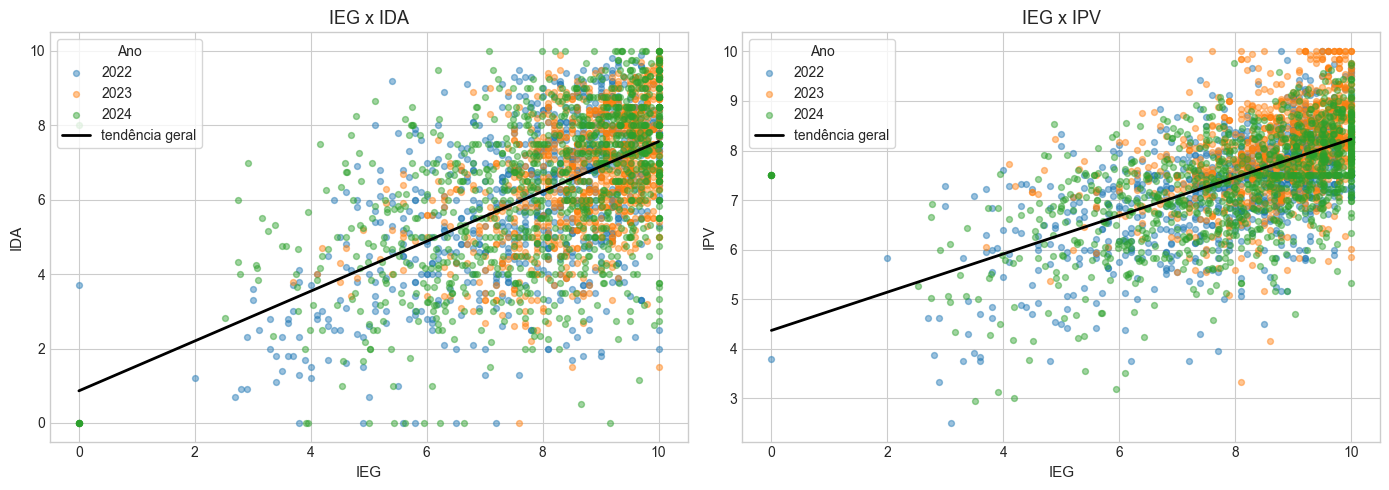


**Leitura analítica:** a correlação geral entre `IEG` e `IDA` é **0.54**; entre `IEG` e `IPV`, **0.56**. Isso sugere que engajamento é um bom candidato tanto para explicar desempenho quanto para antecipar ponto de virada, sem assumir causalidade.


In [25]:
corr_ieg = []
for ano, group in base.groupby("ano"):
    corr = group[["ieg", "ida", "ipv", "inde"]].corr(numeric_only=True).loc["ieg", ["ida", "ipv", "inde"]]
    corr_ieg.append({"ano": ano, "corr_ieg_ida": corr["ida"], "corr_ieg_ipv": corr["ipv"], "corr_ieg_inde": corr["inde"]})
corr_ieg = pd.DataFrame(corr_ieg).set_index("ano")
display(corr_ieg.round(3))

quartil_ieg = base.dropna(subset=["ieg"]).copy()
quartil_ieg["quartil_ieg"] = pd.qcut(
    quartil_ieg["ieg"],
    q=4,
    labels=["Q1 baixo", "Q2", "Q3", "Q4 alto"],
    duplicates="drop",
)
quartil_ieg_summary = (
    quartil_ieg.groupby(["ano", "quartil_ieg"], observed=True)
    .agg(alunos=("ra", "count"), ida_medio=("ida", "mean"), ipv_medio=("ipv", "mean"), inde_medio=("inde", "mean"))
    .round(3)
)
display(quartil_ieg_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_scatter_with_fit(base, "ieg", "ida", axes[0], "IEG x IDA")
plot_scatter_with_fit(base, "ieg", "ipv", axes[1], "IEG x IPV")
plt.tight_layout()
plt.show()

display(Markdown(f'''
**Leitura analítica:** a correlação geral entre `IEG` e `IDA` é **{base[['ieg', 'ida']].corr().iloc[0, 1]:.2f}**; entre `IEG` e `IPV`, **{base[['ieg', 'ipv']].corr().iloc[0, 1]:.2f}**. Isso sugere que engajamento é um bom candidato tanto para explicar desempenho quanto para antecipar ponto de virada, sem assumir causalidade.
'''))

## 9. IAA - Coerência entre autoavaliação, desempenho e engajamento

Pergunta de negócio: **as percepções dos alunos sobre si mesmos são coerentes com desempenho real e engajamento?**

coerencia_iaa_ida,Coerente,IAA abaixo do desempenho,IAA acima do desempenho
ano,,,
2022,33.400,5.000,61.600
2023,33.600,21.500,44.900
2024,35.600,3.600,60.800


,iaa_medio,ida_medio,ieg_medio,gap_iaa_ida_medio,pct_iaa_zero
ano,,,,,
2022,8.274,6.093,7.891,2.182,4.535
2023,6.903,6.663,8.699,0.255,18.738
2024,8.544,6.351,7.375,2.194,1.730


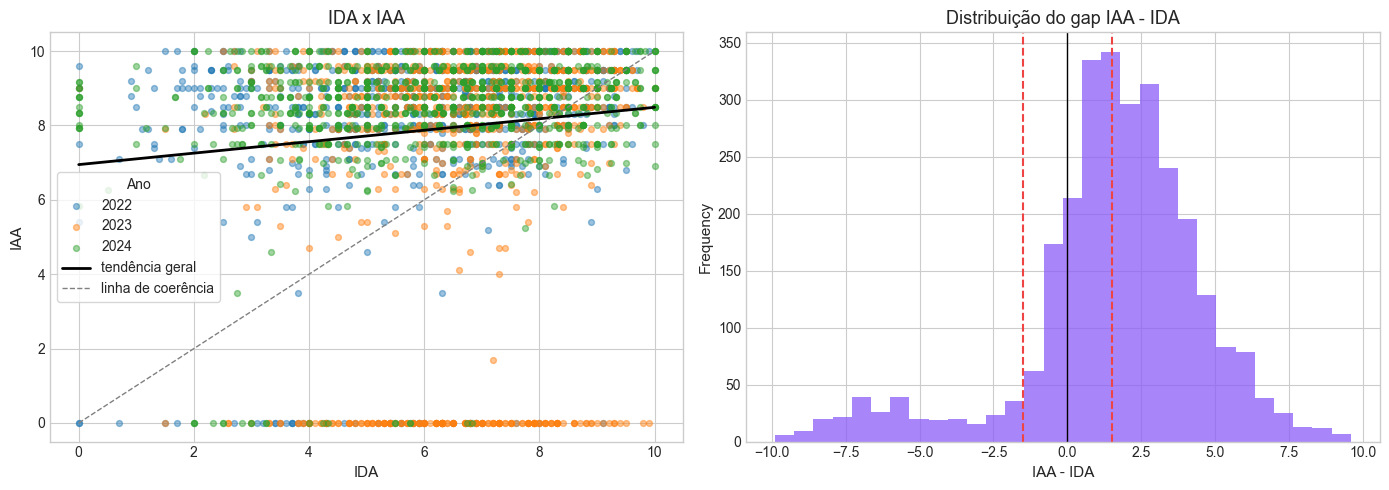

,ano,ra,fase_raw,iaa,ida,ieg,gap_iaa_ida,coerencia_iaa_ida
293,2022,RA-294,3,9.600,0.000,5.800,9.600,IAA acima do desempenho
2919,2024,RA-1229,7E,9.168,0.000,0.000,9.168,IAA acima do desempenho
2906,2024,RA-270,7E,9.168,0.000,0.000,9.168,IAA acima do desempenho
2068,2024,RA-1392,ALFA,9.002,0.000,5.625,9.002,IAA acima do desempenho
1933,2024,RA-1311,ALFA,9.002,0.000,9.167,9.002,IAA acima do desempenho
488,2022,RA-489,1,9.000,0.000,7.200,9.000,IAA acima do desempenho
995,2023,RA-948,ALFA,9.000,0.000,7.600,9.000,IAA acima do desempenho
2918,2024,RA-1228,7E,8.751,0.000,0.000,8.751,IAA acima do desempenho
2908,2024,RA-153,7E,8.751,0.000,0.000,8.751,IAA acima do desempenho
2915,2024,RA-1227,7E,8.751,0.000,0.000,8.751,IAA acima do desempenho



**Leitura analítica:** gaps positivos altos indicam alunos que se autoavaliam melhor do que o desempenho acadêmico observado; gaps negativos altos indicam possível subestimação ou baixa autopercepção. Ambos são úteis para segmentação e para investigar risco de queda futura.


In [26]:
base["gap_iaa_ida"] = base["iaa"] - base["ida"]
base["gap_iaa_ieg"] = base["iaa"] - base["ieg"]


def faixa_gap(value, limite=1.5):
    if pd.isna(value):
        return np.nan
    if value > limite:
        return "IAA acima do desempenho"
    if value < -limite:
        return "IAA abaixo do desempenho"
    return "Coerente"


base["coerencia_iaa_ida"] = base["gap_iaa_ida"].map(faixa_gap)
base["coerencia_iaa_ieg"] = base["gap_iaa_ieg"].map(faixa_gap)

coerencia_ida = (
    pd.crosstab(base["ano"], base["coerencia_iaa_ida"], normalize="index")
    .mul(100)
    .round(1)
)
display(coerencia_ida)

gap_summary = (
    base.groupby("ano")
    .agg(
        iaa_medio=("iaa", "mean"),
        ida_medio=("ida", "mean"),
        ieg_medio=("ieg", "mean"),
        gap_iaa_ida_medio=("gap_iaa_ida", "mean"),
        pct_iaa_zero=("iaa", lambda s: s.eq(0).mean() * 100),
    )
    .round(3)
)
display(gap_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_scatter_with_fit(base, "ida", "iaa", axes[0], "IDA x IAA")
axes[0].plot([0, 10], [0, 10], linestyle="--", color="gray", linewidth=1, label="linha de coerência")
axes[0].legend(title="Ano", frameon=True)

base["gap_iaa_ida"].dropna().plot(kind="hist", bins=30, ax=axes[1], color="#8b5cf6", alpha=0.75)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].axvline(1.5, color="#ef4444", linestyle="--")
axes[1].axvline(-1.5, color="#ef4444", linestyle="--")
axes[1].set_title("Distribuição do gap IAA - IDA")
axes[1].set_xlabel("IAA - IDA")
plt.tight_layout()
plt.show()

display(
    base.dropna(subset=["gap_iaa_ida"])
    .loc[:, ["ano", "ra", "fase_raw", "iaa", "ida", "ieg", "gap_iaa_ida", "coerencia_iaa_ida"]]
    .sort_values("gap_iaa_ida", ascending=False)
    .head(10)
)

display(Markdown('''
**Leitura analítica:** gaps positivos altos indicam alunos que se autoavaliam melhor do que o desempenho acadêmico observado; gaps negativos altos indicam possível subestimação ou baixa autopercepção. Ambos são úteis para segmentação e para investigar risco de queda futura.
'''))

## 10. IPS - Sinais psicossociais antes de queda de IDA ou IEG

Pergunta de negócio: **há padrões psicossociais que antecedem quedas de desempenho acadêmico ou engajamento?**

Aqui a análise usa apenas alunos que aparecem em anos consecutivos. Como a base é anual, "antecede" significa: indicador no ano atual versus queda no ano seguinte.

**Comparação por queda futura de IDA >= 1 ponto:**

,alunos,ips_medio,ida_atual,ieg_atual,delta_ida_prox,delta_ieg_prox
queda_ida_prox,,,,,,
False,917,6.061,6.380,8.526,0.674,-0.167
True,386,5.723,7.326,8.782,-2.191,-0.972


**Comparação por queda futura de IEG >= 1 ponto:**

,alunos,ips_medio,ida_atual,ieg_atual,delta_ida_prox,delta_ieg_prox
queda_ieg_prox,,,,,,
False,1000,6.109,6.765,8.548,0.061,0.271
True,303,5.473,6.333,8.781,-1.098,-2.583


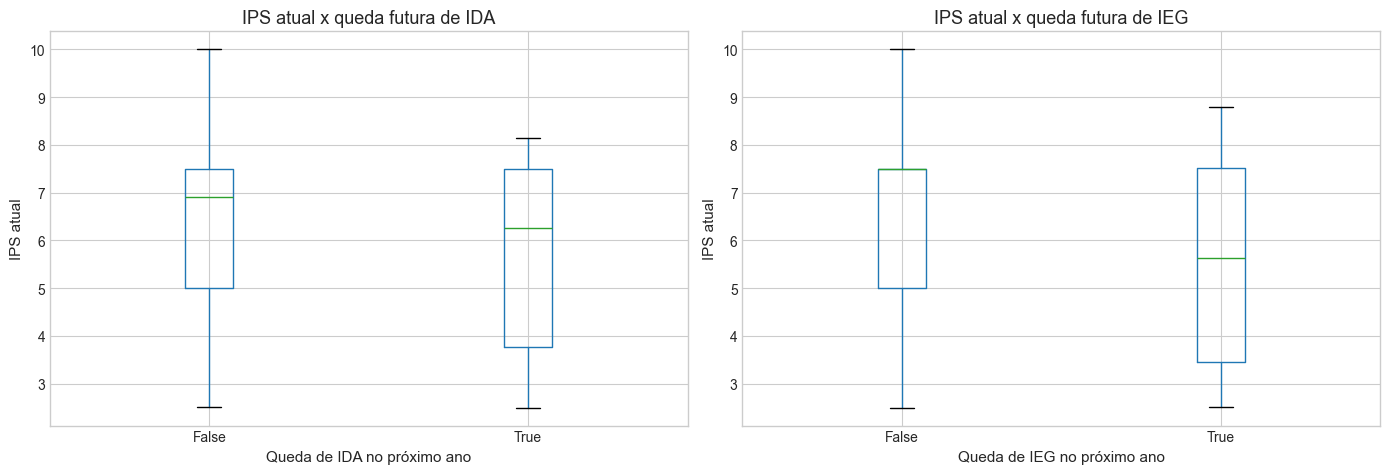


**Leitura analítica:** a análise longitudinal usa **897 alunos** com pelo menos um par de anos consecutivos. Se o `IPS` médio dos grupos com queda futura for menor, ele pode entrar como alerta antecedente; se a diferença for pequena, `IPS` talvez funcione melhor combinado com `IDA`, `IEG`, `IPP` e histórico do próprio aluno.


In [27]:
panel = base.sort_values(["ra", "ano"]).copy()
for metric in ["ida", "ieg", "ips", "ipp", "ipv", "inde"]:
    panel[f"{metric}_next"] = panel.groupby("ra")[metric].shift(-1)
    panel[f"delta_{metric}_next"] = panel[f"{metric}_next"] - panel[metric]
panel["ano_next"] = panel.groupby("ra")["ano"].shift(-1)
panel["tem_ano_consecutivo"] = panel["ano_next"].eq(panel["ano"] + 1)
panel["queda_ida_prox"] = panel["tem_ano_consecutivo"] & panel["delta_ida_next"].le(-1)
panel["queda_ieg_prox"] = panel["tem_ano_consecutivo"] & panel["delta_ieg_next"].le(-1)

panel_valid = panel[panel["tem_ano_consecutivo"]].copy()


def compare_signal(outcome):
    d = panel_valid.dropna(subset=["ips", outcome])
    return (
        d.groupby(outcome)
        .agg(
            alunos=("ra", "count"),
            ips_medio=("ips", "mean"),
            ida_atual=("ida", "mean"),
            ieg_atual=("ieg", "mean"),
            delta_ida_prox=("delta_ida_next", "mean"),
            delta_ieg_prox=("delta_ieg_next", "mean"),
        )
        .round(3)
    )


display(Markdown("**Comparação por queda futura de IDA >= 1 ponto:**"))
display(compare_signal("queda_ida_prox"))
display(Markdown("**Comparação por queda futura de IEG >= 1 ponto:**"))
display(compare_signal("queda_ieg_prox"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
panel_valid.dropna(subset=["ips", "queda_ida_prox"]).boxplot(column="ips", by="queda_ida_prox", ax=axes[0])
axes[0].set_title("IPS atual x queda futura de IDA")
axes[0].set_xlabel("Queda de IDA no próximo ano")
axes[0].set_ylabel("IPS atual")
panel_valid.dropna(subset=["ips", "queda_ieg_prox"]).boxplot(column="ips", by="queda_ieg_prox", ax=axes[1])
axes[1].set_title("IPS atual x queda futura de IEG")
axes[1].set_xlabel("Queda de IEG no próximo ano")
axes[1].set_ylabel("IPS atual")
plt.suptitle("")
plt.tight_layout()
plt.show()

display(Markdown(f'''
**Leitura analítica:** a análise longitudinal usa **{panel_valid['ra'].nunique():,} alunos** com pelo menos um par de anos consecutivos. Se o `IPS` médio dos grupos com queda futura for menor, ele pode entrar como alerta antecedente; se a diferença for pequena, `IPS` talvez funcione melhor combinado com `IDA`, `IEG`, `IPP` e histórico do próprio aluno.
'''))

## 11. IPP - Confirma ou contradiz a defasagem do IAN?

Pergunta de negócio: **as avaliações psicopedagógicas confirmam ou contradizem a defasagem identificada pelo IAN?**

Observação: `IPP` não está preenchido em 2022 na base disponibilizada; por isso essa análise concentra 2023 e 2024.

,ano,variavel,corr_ipp
4,2023,ipv,0.516
5,2023,inde,0.435
2,2023,ida,0.351
3,2023,ieg,0.244
1,2023,defasagem,0.190
0,2023,ian,0.095
10,2024,ipv,0.750
11,2024,inde,0.637
9,2024,ieg,0.409
8,2024,ida,0.395


perfil_ipp_defasagem,Alerta oculto: IPP baixo sem defasagem,Coerente sem risco aparente,Confirma risco: defasagem + IPP baixo,Contradição: defasagem com IPP bom,Zona intermediária
ano,,,,,
2023,3.500,33.700,5.300,43.500,14.000
2024,1.900,41.500,3.500,37.400,15.700


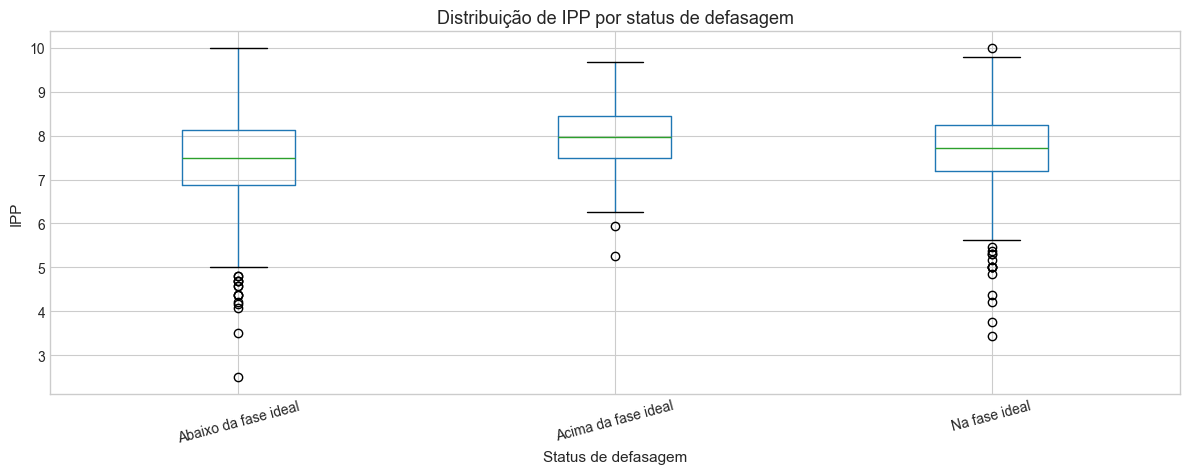


**Leitura analítica:** quando `IPP` baixo aparece junto com defasagem, há convergência de evidências. Quando há defasagem com `IPP` bom, a defasagem pode estar mais ligada à trajetória escolar/idade do que a uma limitação psicopedagógica. Quando `IPP` baixo aparece sem defasagem, surge um alerta preventivo.


In [28]:
ipp_cols = ["ipp", "ian", "defasagem", "ida", "ieg", "ipv", "inde"]
ipp_corr = corr_by_year(base.dropna(subset=["ipp"]), ipp_cols, "ipp")
display(ipp_corr.round(3))


def classifica_ipp_defas(row):
    if pd.isna(row["ipp"]) or pd.isna(row["defasagem"]):
        return np.nan
    tem_defasagem = row["defasagem"] < 0
    ipp_baixo = row["ipp"] < 6
    ipp_bom = row["ipp"] >= 7
    if tem_defasagem and ipp_baixo:
        return "Confirma risco: defasagem + IPP baixo"
    if tem_defasagem and ipp_bom:
        return "Contradição: defasagem com IPP bom"
    if not tem_defasagem and ipp_baixo:
        return "Alerta oculto: IPP baixo sem defasagem"
    if not tem_defasagem and ipp_bom:
        return "Coerente sem risco aparente"
    return "Zona intermediária"


base["perfil_ipp_defasagem"] = base.apply(classifica_ipp_defas, axis=1)
perfil_ipp = (
    pd.crosstab(base["ano"], base["perfil_ipp_defasagem"], normalize="index")
    .mul(100)
    .round(1)
)
display(perfil_ipp)

fig, ax = plt.subplots(figsize=(12, 5))
plot_df = base.dropna(subset=["ipp", "status_defasagem"])
plot_df.boxplot(column="ipp", by="status_defasagem", ax=ax)
ax.set_title("Distribuição de IPP por status de defasagem")
ax.set_xlabel("Status de defasagem")
ax.set_ylabel("IPP")
plt.suptitle("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

display(Markdown('''
**Leitura analítica:** quando `IPP` baixo aparece junto com defasagem, há convergência de evidências. Quando há defasagem com `IPP` bom, a defasagem pode estar mais ligada à trajetória escolar/idade do que a uma limitação psicopedagógica. Quando `IPP` baixo aparece sem defasagem, surge um alerta preventivo.
'''))

## 12. IPV - Comportamentos associados ao ponto de virada

Pergunta de negócio: **quais comportamentos acadêmicos, emocionais ou de engajamento mais influenciam o IPV ao longo do tempo?**

Aqui usamos duas leituras: correlação simples e importância preditiva em Random Forest. A segunda indica poder preditivo, não causalidade.

,ano,variavel,corr_ipv
0,2022,ida,0.617
1,2022,ieg,0.589
2,2022,iaa,0.256
3,2022,ips,0.208
6,2022,defasagem,0.173
5,2022,ian,0.111
7,2022,fase_ordem,-0.110
8,2022,idade,-0.195
4,2022,ipp,NaN
9,2023,ida,0.544


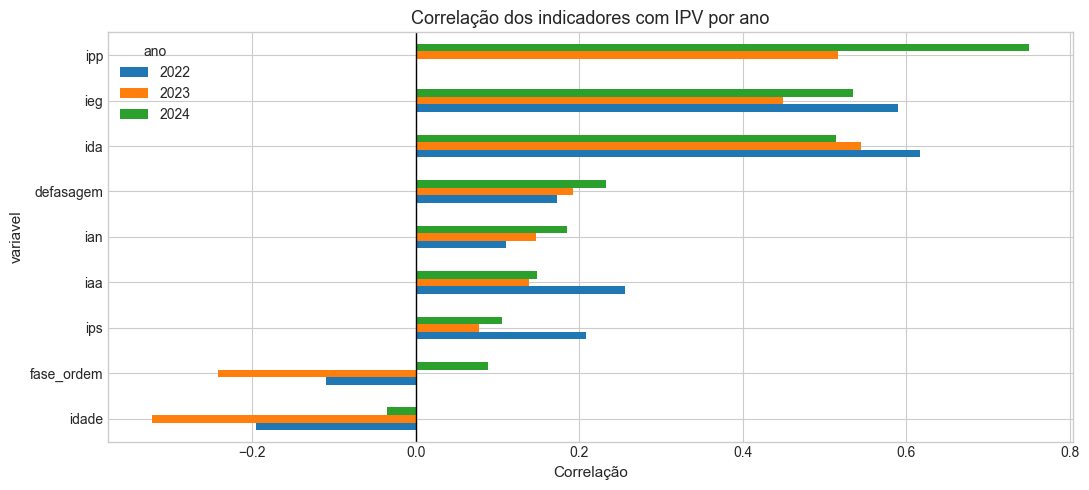

,modelo,linhas_modelo,MAE,R2
0,RandomForest IPV,2852,0.512,0.601


,variavel,importancia,desvio
4,ipp,0.272,0.022
1,ieg,0.199,0.020
0,ida,0.186,0.022
3,ips,0.041,0.006
7,fase_ordem,0.013,0.004
8,idade,0.007,0.003
2,iaa,0.006,0.003
6,defasagem,0.003,0.001
5,ian,0.001,0.001


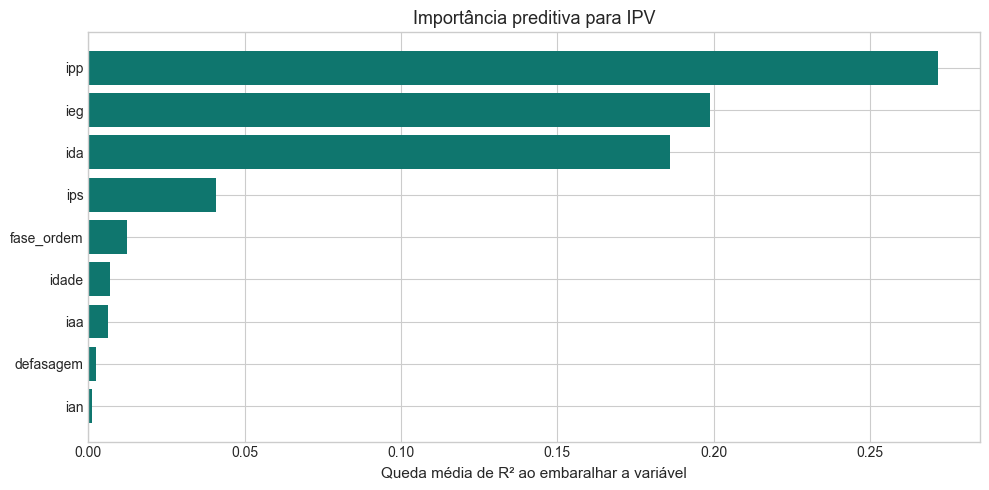


**Leitura analítica:** em geral, `IDA`, `IEG` e `IPP` aparecem como variáveis relevantes para explicar `IPV`. Para uma etapa de ML, teste modelos com e sem `IPP`, pois a ausência de `IPP` em 2022 pode impactar cobertura e comparação histórica.


In [29]:
features_ipv = ["ida", "ieg", "iaa", "ips", "ipp", "ian", "defasagem", "fase_ordem", "idade"]
corr_ipv = corr_by_year(base, features_ipv + ["ipv"], "ipv")
display(corr_ipv.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
corr_pivot = corr_ipv.pivot(index="variavel", columns="ano", values="corr_ipv").sort_values(2024, ascending=True)
corr_pivot.plot(kind="barh", ax=ax)
ax.set_title("Correlação dos indicadores com IPV por ano")
ax.set_xlabel("Correlação")
ax.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

if SKLEARN_OK:
    model_data_ipv = base.dropna(subset=["ipv"]).copy()
    X = model_data_ipv[features_ipv]
    y = model_data_ipv["ipv"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    model_ipv = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42)),
        ]
    )
    model_ipv.fit(X_train, y_train)
    pred = model_ipv.predict(X_test)
    perf_ipv = pd.DataFrame(
        [{"modelo": "RandomForest IPV", "linhas_modelo": len(model_data_ipv), "MAE": mean_absolute_error(y_test, pred), "R2": r2_score(y_test, pred)}]
    )
    display(perf_ipv.round(3))

    perm = permutation_importance(model_ipv, X_test, y_test, n_repeats=20, random_state=42)
    importance_ipv = (
        pd.DataFrame({"variavel": features_ipv, "importancia": perm.importances_mean, "desvio": perm.importances_std})
        .sort_values("importancia", ascending=False)
    )
    display(importance_ipv.round(4))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(importance_ipv["variavel"], importance_ipv["importancia"], color="#0f766e")
    ax.invert_yaxis()
    ax.set_title("Importância preditiva para IPV")
    ax.set_xlabel("Queda média de R² ao embaralhar a variável")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown(f"`sklearn` não está disponível neste kernel: {SKLEARN_ERROR}"))

display(Markdown('''
**Leitura analítica:** em geral, `IDA`, `IEG` e `IPP` aparecem como variáveis relevantes para explicar `IPV`. Para uma etapa de ML, teste modelos com e sem `IPP`, pois a ausência de `IPP` em 2022 pode impactar cobertura e comparação histórica.
'''))

## 13. Multidimensionalidade - Combinações que elevam o INDE

Pergunta de negócio: **quais combinações de indicadores elevam mais a nota global do aluno?**

Nesta seção, analisamos correlação, importância preditiva e perfis combinados de `IDA + IEG + IPS + IPP`.

,ano,variavel,corr_inde
1,2022,ida,0.818
2,2022,ieg,0.802
6,2022,ipv,0.789
3,2022,iaa,0.455
7,2022,defasagem,0.407
0,2022,ian,0.395
4,2022,ips,0.269
8,2022,fase_ordem,-0.182
9,2022,idade,-0.341
5,2022,ipp,NaN


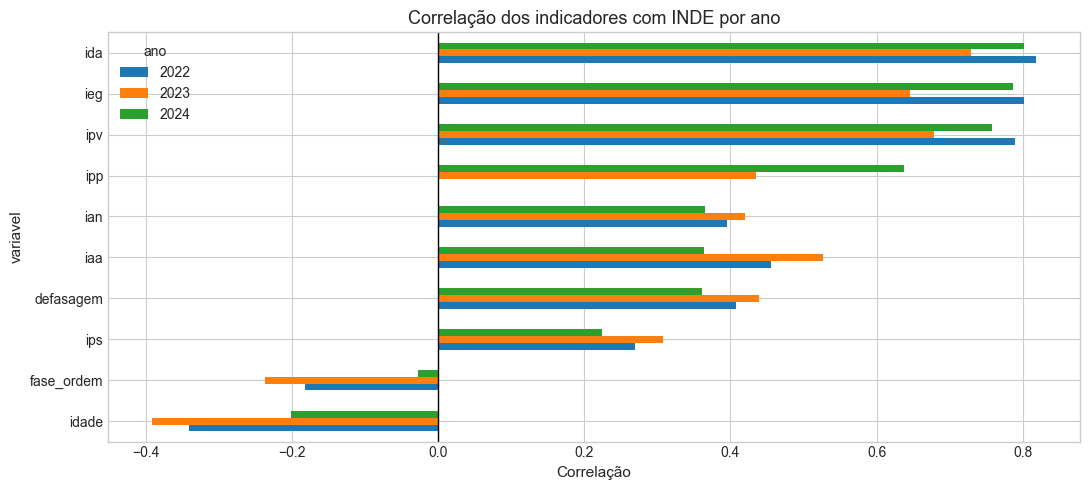

,modelo,linhas_modelo,MAE,R2
0,RandomForest INDE,2845,0.135,0.962


,variavel,importancia,desvio
1,ida,0.382,0.017
2,ieg,0.225,0.010
3,iaa,0.104,0.005
6,ipv,0.086,0.004
4,ips,0.036,0.002
0,ian,0.035,0.003
7,defasagem,0.031,0.002
5,ipp,0.003,0.000
8,fase_ordem,0.000,0.000
9,idade,0.000,0.000


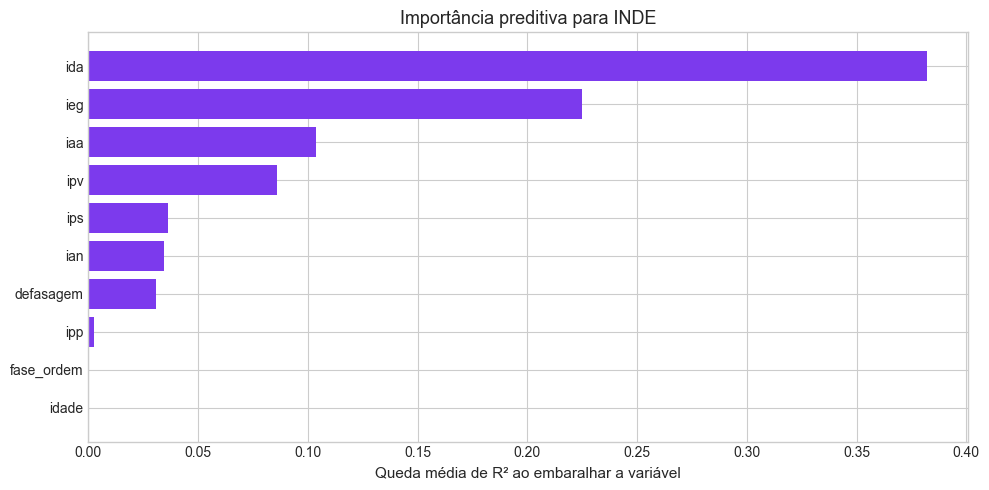

,alunos,inde_medio,ida_medio,ieg_medio,ips_medio,ipp_medio
combo_ida_ieg_ips_ipp,,,,,,
IDA alto (>=8) | IEG alto (>=8) | IPS médio (6-8) | IPP alto (>=8),133,8.569,8.889,9.440,7.194,8.696
IDA alto (>=8) | IEG alto (>=8) | IPS médio (6-8) | IPP médio (6-8),118,8.321,8.726,9.313,7.158,7.409
IDA médio (6-8) | IEG alto (>=8) | IPS médio (6-8) | IPP alto (>=8),126,8.142,7.212,9.323,7.246,8.446
IDA alto (>=8) | IEG alto (>=8) | IPS baixo (<6) | IPP alto (>=8),64,8.112,8.855,9.332,3.686,8.771
IDA alto (>=8) | IEG alto (>=8) | IPS baixo (<6) | IPP médio (6-8),46,7.940,8.788,9.336,3.763,7.312
IDA médio (6-8) | IEG alto (>=8) | IPS médio (6-8) | IPP médio (6-8),205,7.826,7.169,9.202,7.224,7.430
IDA médio (6-8) | IEG alto (>=8) | IPS baixo (<6) | IPP alto (>=8),97,7.694,7.108,9.351,3.462,8.519
IDA baixo (<6) | IEG alto (>=8) | IPS médio (6-8) | IPP alto (>=8),32,7.649,4.867,9.223,7.336,8.361
IDA médio (6-8) | IEG médio (6-8) | IPS médio (6-8) | IPP alto (>=8),24,7.525,6.990,7.285,7.330,8.365


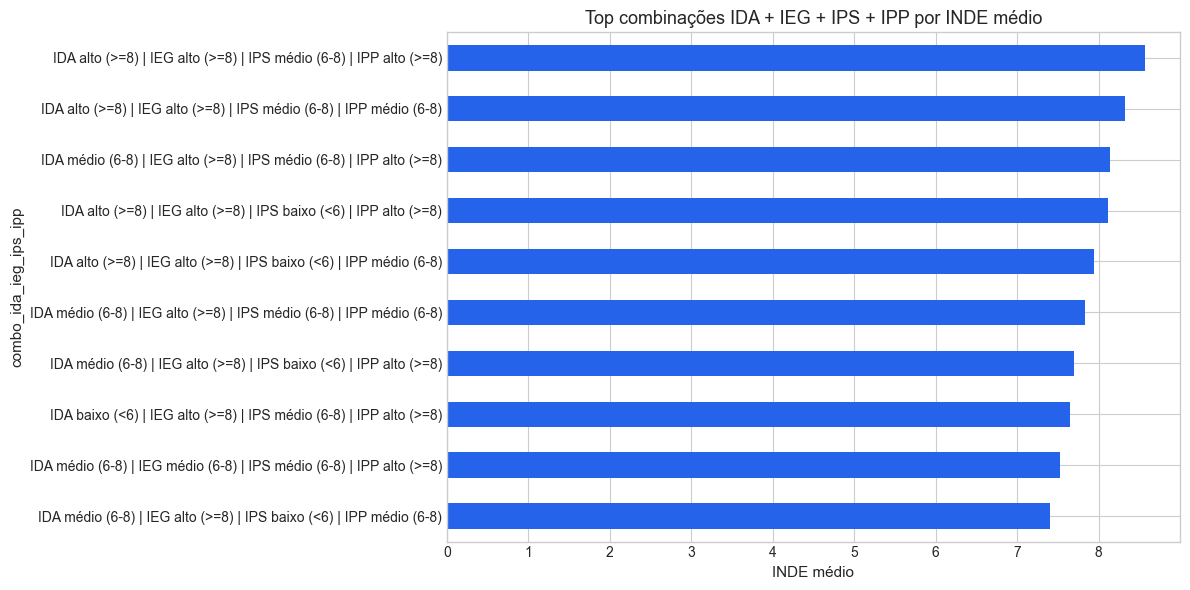


**Leitura analítica:** perfis com `IDA` e `IEG` altos tendem a subir no ranking de `INDE`; `IPP` ajuda a separar alunos com potencial de ponto de virada mais favorável. A combinação por faixas é uma boa forma de criar features categóricas interpretáveis para modelos e dashboards.


In [30]:
features_inde = ["ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv", "defasagem", "fase_ordem", "idade"]
corr_inde = corr_by_year(base, features_inde + ["inde"], "inde")
display(corr_inde.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
corr_inde_pivot = corr_inde.pivot(index="variavel", columns="ano", values="corr_inde").sort_values(2024, ascending=True)
corr_inde_pivot.plot(kind="barh", ax=ax)
ax.set_title("Correlação dos indicadores com INDE por ano")
ax.set_xlabel("Correlação")
ax.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

if SKLEARN_OK:
    model_data_inde = base.dropna(subset=["inde"]).copy()
    X = model_data_inde[features_inde]
    y = model_data_inde["inde"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    model_inde = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42)),
        ]
    )
    model_inde.fit(X_train, y_train)
    pred = model_inde.predict(X_test)
    perf_inde = pd.DataFrame(
        [{"modelo": "RandomForest INDE", "linhas_modelo": len(model_data_inde), "MAE": mean_absolute_error(y_test, pred), "R2": r2_score(y_test, pred)}]
    )
    display(perf_inde.round(3))

    perm = permutation_importance(model_inde, X_test, y_test, n_repeats=20, random_state=42)
    importance_inde = (
        pd.DataFrame({"variavel": features_inde, "importancia": perm.importances_mean, "desvio": perm.importances_std})
        .sort_values("importancia", ascending=False)
    )
    display(importance_inde.round(4))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(importance_inde["variavel"], importance_inde["importancia"], color="#7c3aed")
    ax.invert_yaxis()
    ax.set_title("Importância preditiva para INDE")
    ax.set_xlabel("Queda média de R² ao embaralhar a variável")
    plt.tight_layout()
    plt.show()

combo_cols = ["ida", "ieg", "ips", "ipp"]
combo_df = base.dropna(subset=["inde"] + combo_cols).copy()
for col in combo_cols:
    combo_df[f"{col}_faixa"] = pd.cut(
        combo_df[col],
        bins=[-np.inf, 6, 8, np.inf],
        labels=["baixo (<6)", "médio (6-8)", "alto (>=8)"],
    )

combo_df["combo_ida_ieg_ips_ipp"] = combo_df[[f"{col}_faixa" for col in combo_cols]].astype(str).agg(
    lambda row: " | ".join([f"{col.upper()} {row[f'{col}_faixa']}" for col in combo_cols]),
    axis=1,
)

combo_summary = (
    combo_df.groupby("combo_ida_ieg_ips_ipp")
    .agg(
        alunos=("ra", "count"),
        inde_medio=("inde", "mean"),
        ida_medio=("ida", "mean"),
        ieg_medio=("ieg", "mean"),
        ips_medio=("ips", "mean"),
        ipp_medio=("ipp", "mean"),
    )
    .query("alunos >= 20")
    .sort_values("inde_medio", ascending=False)
    .round(3)
)
display(combo_summary.head(15))

fig, ax = plt.subplots(figsize=(12, 6))
combo_summary.head(10).sort_values("inde_medio")["inde_medio"].plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Top combinações IDA + IEG + IPS + IPP por INDE médio")
ax.set_xlabel("INDE médio")
plt.tight_layout()
plt.show()

display(Markdown('''
**Leitura analítica:** perfis com `IDA` e `IEG` altos tendem a subir no ranking de `INDE`; `IPP` ajuda a separar alunos com potencial de ponto de virada mais favorável. A combinação por faixas é uma boa forma de criar features categóricas interpretáveis para modelos e dashboards.
'''))

## 14. Base analítica para Machine Learning

Sugestão de modelagem posterior:
- **Regressão:** prever `INDE` ou `IPV`.
- **Classificação:** prever risco de defasagem, queda futura de `IDA`, queda futura de `IEG` ou baixa classificação de Pedra.
- **Ranking/priorização:** ordenar alunos por probabilidade de queda ou necessidade de intervenção.

In [31]:
ml_features = [
    "ano", "fase_ordem", "idade", "ano_ingresso",
    "ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv", "inde",
    "defasagem", "atraso_fase", "gap_iaa_ida", "gap_iaa_ieg",
    "genero", "instituicao", "pedra", "status_defasagem", "situacao",
]

ml_base = base[ml_features].copy()
ml_base["risco_defasagem"] = ml_base["defasagem"].lt(0)
ml_base["baixo_inde"] = ml_base["inde"].lt(6)

queda_flags = panel[["ano", "ra", "queda_ida_prox", "queda_ieg_prox", "delta_ida_next", "delta_ieg_next"]]
ml_base_preview = ml_base.copy()

feature_catalog = pd.DataFrame(
    [
        {"variavel": "ian / defasagem / atraso_fase", "tipo": "numérica", "uso_ml": "risco de defasagem e contexto de nível"},
        {"variavel": "ida / mat / por / ing", "tipo": "numérica", "uso_ml": "desempenho acadêmico e tendência"},
        {"variavel": "ieg", "tipo": "numérica", "uso_ml": "engajamento, provável driver de IDA/IPV"},
        {"variavel": "iaa e gaps IAA-IDA/IEG", "tipo": "numérica derivada", "uso_ml": "coerência de autopercepção"},
        {"variavel": "ips", "tipo": "numérica", "uso_ml": "sinal psicossocial e alerta preventivo"},
        {"variavel": "ipp", "tipo": "numérica", "uso_ml": "avaliação psicopedagógica; atenção à ausência em 2022"},
        {"variavel": "fase_ordem / idade / ano_ingresso", "tipo": "numérica", "uso_ml": "contexto de trajetória"},
        {"variavel": "genero / instituicao / pedra / situacao", "tipo": "categórica", "uso_ml": "segmentação e controles"},
    ]
)

display(feature_catalog)
display(ml_base.head())
display(
    ml_base.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("% nulos")
    .to_frame()
    .round(1)
)

display(Markdown('''
**Próximo passo recomendado:** decidir o alvo principal de ML. Para impacto operacional, bons alvos são `queda_ida_prox`, `queda_ieg_prox`, `risco_defasagem` ou `INDE` futuro. Para evitar vazamento de dados, quando o alvo for futuro, use apenas variáveis do ano anterior.
'''))

,variavel,tipo,uso_ml
0,ian / defasagem / atraso_fase,numérica,risco de defasagem e contexto de nível
1,ida / mat / por / ing,numérica,desempenho acadêmico e tendência
2,ieg,numérica,"engajamento, provável driver de IDA/IPV"
3,iaa e gaps IAA-IDA/IEG,numérica derivada,coerência de autopercepção
4,ips,numérica,sinal psicossocial e alerta preventivo
5,ipp,numérica,avaliação psicopedagógica; atenção à ausência ...
6,fase_ordem / idade / ano_ingresso,numérica,contexto de trajetória
7,genero / instituicao / pedra / situacao,categórica,segmentação e controles


,ano,fase_ordem,idade,ano_ingresso,ian,ida,ieg,iaa,ips,ipp,ipv,inde,defasagem,atraso_fase,gap_iaa_ida,gap_iaa_ieg,genero,instituicao,pedra,status_defasagem,situacao,risco_defasagem,baixo_inde
0,2022,7,19.000,2016,5.000,4.000,4.100,8.300,5.600,NaN,7.278,5.783,-1,1,4.300,4.200,Menina,Escola Pública,Quartzo,Abaixo da fase ideal,NaN,True,True
1,2022,7,17.000,2017,10.000,6.800,5.200,8.800,6.300,NaN,6.778,7.055,0,0,2.000,3.600,Menina,Rede Decisão,Ametista,Na fase ideal,NaN,False,False
2,2022,7,17.000,2016,10.000,5.600,7.900,0.000,5.600,NaN,7.556,6.591,0,0,-5.600,-7.900,Menina,Rede Decisão,Ágata,Na fase ideal,NaN,False,False
3,2022,7,17.000,2017,10.000,5.000,4.500,8.800,5.600,NaN,5.278,5.951,0,0,3.800,4.300,Menino,Rede Decisão,Quartzo,Na fase ideal,NaN,False,True
4,2022,7,17.000,2016,10.000,5.200,8.600,7.900,5.600,NaN,7.389,7.427,0,0,2.700,-0.700,Menina,Rede Decisão,Ametista,Na fase ideal,NaN,False,False


,% nulos
situacao,61.800
ipp,34.300
idade,13.200
inde,6.100
gap_iaa_ida,5.900
ida,5.900
gap_iaa_ieg,5.900
ipv,5.900
ips,5.600
iaa,5.400



**Próximo passo recomendado:** decidir o alvo principal de ML. Para impacto operacional, bons alvos são `queda_ida_prox`, `queda_ieg_prox`, `risco_defasagem` ou `INDE` futuro. Para evitar vazamento de dados, quando o alvo for futuro, use apenas variáveis do ano anterior.


## 15. Resumo executivo

Esta célula consolida as principais leituras numéricas para orientar a próxima etapa do projeto.

In [32]:
def safe_corr(a, b):
    return base[[a, b]].corr().iloc[0, 1]


resumo = pd.DataFrame(
    [
        {
            "tema": "IAN / Defasagem",
            "ponto_analitico": f"IAN médio 2024 = {ian_year.loc[2024, 'ian_medio']:.2f}; alunos abaixo da fase ideal = {pct_fmt(ian_year.loc[2024, 'pct_abaixo_fase'])}.",
        },
        {
            "tema": "IDA",
            "ponto_analitico": f"IDA de 2023 para 2024 está {classifica_tendencia(delta_23_24)} ({delta_23_24:+.2f}).",
        },
        {
            "tema": "IEG",
            "ponto_analitico": f"Correlação IEG-IDA = {safe_corr('ieg', 'ida'):.2f}; IEG-IPV = {safe_corr('ieg', 'ipv'):.2f}.",
        },
        {
            "tema": "IAA",
            "ponto_analitico": "Gaps IAA-IDA/IEG permitem identificar superestimação, subestimação e coerência de autopercepção.",
        },
        {
            "tema": "IPS",
            "ponto_analitico": f"Há {panel_valid['ra'].nunique():,} alunos com histórico em anos consecutivos para testar queda futura.",
        },
        {
            "tema": "IPP",
            "ponto_analitico": "IPP é útil em 2023-2024, mas deve ser tratado com cuidado por ausência em 2022.",
        },
        {
            "tema": "IPV / INDE",
            "ponto_analitico": f"Correlação geral IPV-INDE = {safe_corr('ipv', 'inde'):.2f}; IDA-INDE = {safe_corr('ida', 'inde'):.2f}; IEG-INDE = {safe_corr('ieg', 'inde'):.2f}.",
        },
    ]
)
display(resumo)

display(Markdown('''
**Hipótese central para ML:** alunos com pior combinação de defasagem, queda/baixo IDA, baixo engajamento e sinais psicopedagógicos/psicossociais desfavoráveis devem apresentar maior risco de queda futura e menor INDE. O modelo deve ser temporal: treinar com variáveis de um ano para prever resultado do ano seguinte sempre que possível.
'''))

,tema,ponto_analitico
0,IAN / Defasagem,IAN médio 2024 = 7.68; alunos abaixo da fase i...
1,IDA,IDA de 2023 para 2024 está caindo (-0.31).
2,IEG,Correlação IEG-IDA = 0.54; IEG-IPV = 0.56.
3,IAA,Gaps IAA-IDA/IEG permitem identificar superest...
4,IPS,Há 897 alunos com histórico em anos consecutiv...
5,IPP,"IPP é útil em 2023-2024, mas deve ser tratado ..."
6,IPV / INDE,Correlação geral IPV-INDE = 0.72; IDA-INDE = 0...



**Hipótese central para ML:** alunos com pior combinação de defasagem, queda/baixo IDA, baixo engajamento e sinais psicopedagógicos/psicossociais desfavoráveis devem apresentar maior risco de queda futura e menor INDE. O modelo deve ser temporal: treinar com variáveis de um ano para prever resultado do ano seguinte sempre que possível.
